# Corporate Default Prediction
XGBoost classifier predicting US public company bankruptcy from NYSE/NASDAQ accounting data (1999-2018).

**Dataset:** [American Companies Bankruptcy Prediction](https://www.kaggle.com/datasets/utkarshx27/american-companies-bankruptcy-prediction-dataset) - 78,682 firm-year observations from 8,262 companies.

**Approach:** Temporal train/test split, XGBoost with class weighting, SHAP interpretability.

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, auc,
    confusion_matrix, classification_report, roc_curve
)
import shap
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 30)

## Data Loading

In [2]:
df = pd.read_csv("data/american_bankruptcy.csv")

COLUMN_MAP = {
    "X1": "current_assets",
    "X2": "cogs",
    "X3": "depreciation_amort",
    "X4": "ebitda",
    "X5": "inventory",
    "X6": "net_income",
    "X7": "total_receivables",
    "X8": "market_cap",
    "X9": "net_sales",
    "X10": "total_assets",
    "X11": "total_lt_debt",
    "X12": "ebit",
    "X13": "gross_profit",
    "X14": "total_current_liabilities",
    "X15": "retained_earnings",
    "X16": "total_revenue",
    "X17": "total_liabilities",
    "X18": "total_operating_expenses",
}
df.rename(columns=COLUMN_MAP, inplace=True)

# Encode target: failed=1, alive=0
df["target"] = (df["status_label"] == "failed").astype(int)

# Drop duplicate column (total_revenue is identical to net_sales) and non-feature columns
df.drop(columns=["total_revenue", "status_label", "company_name"], inplace=True)

print(f"Shape: {df.shape}")
print(f"Default rate: {df['target'].mean():.2%}")
df.head()

Shape: (78682, 19)
Default rate: 6.63%


,year,current_assets,cogs,depreciation_amort,ebitda,inventory,net_income,total_receivables,market_cap,net_sales,total_assets,total_lt_debt,ebit,gross_profit,total_current_liabilities,retained_earnings,total_liabilities,total_operating_expenses,target
0,1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,372.7519,1024.333,740.998,180.447,70.658,191.226,163.816,201.026,401.483,935.302,0
1,2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,377.1180,874.255,701.854,179.987,45.790,160.444,125.392,204.065,361.642,809.888,0
2,2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,364.5928,638.721,710.199,217.699,4.711,112.244,150.464,139.603,399.964,611.514,0
3,2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,143.3295,606.337,686.621,164.658,3.573,109.590,203.575,124.106,391.633,575.592,0
4,2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,308.9071,651.958,709.292,248.666,20.811,128.656,131.261,131.884,407.608,604.467,0


## Exploratory Data Analysis

In [3]:
print(f"Default rate: {df['target'].mean():.2%}")
print(f"\nClass distribution:\n{df['target'].value_counts().rename({0: 'alive', 1: 'failed'})}")

Default rate: 6.63%

Class distribution:
target
alive     73462
failed     5220
Name: count, dtype: int64


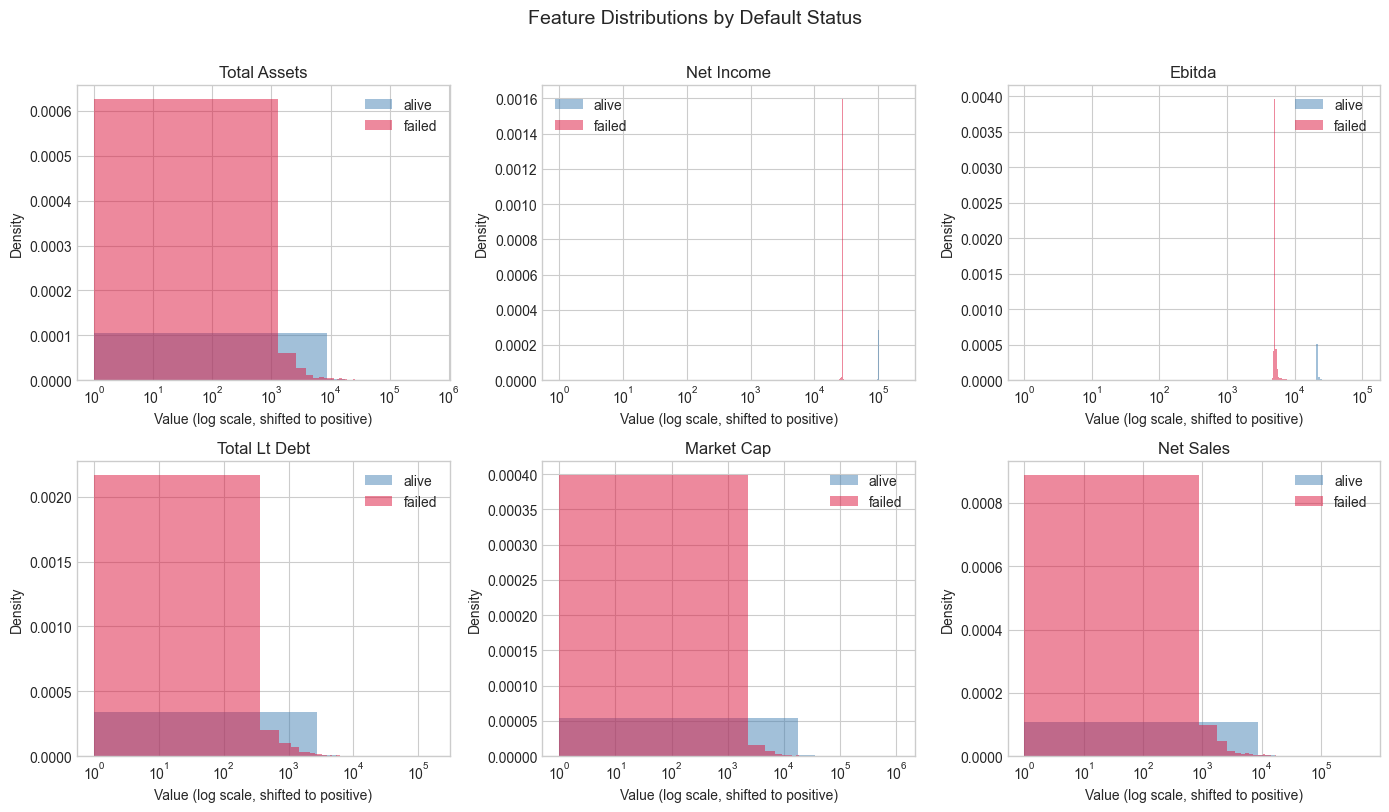

In [4]:
# Feature distributions split by default status - 6 key financial variables
key_features = ["total_assets", "net_income", "ebitda", "total_lt_debt", "market_cap", "net_sales"]
labels = {0: "alive", 1: "failed"}
colors = {0: "steelblue", 1: "crimson"}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(key_features):
    ax = axes[i]
    for target_val in [0, 1]:
        subset = df.loc[df["target"] == target_val, col].dropna()
        # Shift to positive domain for log scale (add small offset if needed)
        shift = max(0, -subset.min()) + 1
        ax.hist(
            subset + shift,
            bins=60,
            alpha=0.5,
            color=colors[target_val],
            label=labels[target_val],
            density=True,
        )
    ax.set_xscale("log")
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel("Value (log scale, shifted to positive)")
    ax.set_ylabel("Density")
    ax.legend()

fig.suptitle("Feature Distributions by Default Status", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

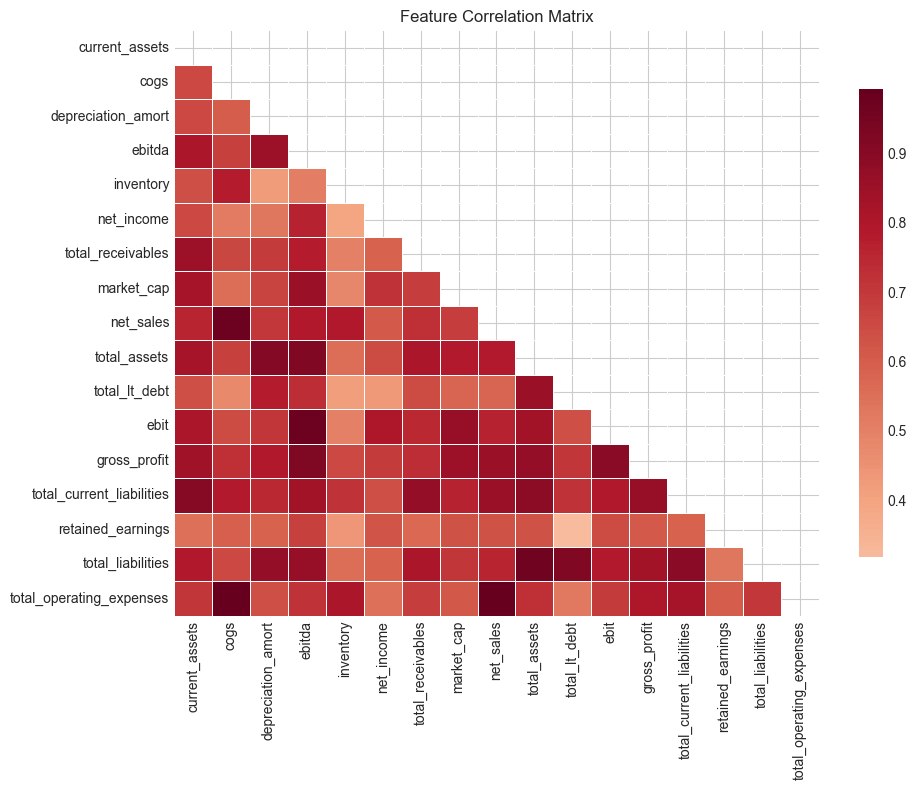

In [5]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = df.select_dtypes(include=[np.number]).drop(columns=["target", "year"]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, ax=ax,
            fmt=".1f", linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

## Feature Engineering

In [6]:
df["current_ratio"] = df["current_assets"] / df["total_assets"].replace(0, np.nan)
df["debt_to_assets"] = df["total_lt_debt"] / df["total_assets"].replace(0, np.nan)
df["net_margin"] = df["net_income"] / df["net_sales"].replace(0, np.nan)
df["ebitda_margin"] = df["ebitda"] / df["net_sales"].replace(0, np.nan)
df["roa"] = df["net_income"] / df["total_assets"].replace(0, np.nan)
df["gross_margin"] = df["gross_profit"] / df["net_sales"].replace(0, np.nan)
df["asset_turnover"] = df["net_sales"] / df["total_assets"].replace(0, np.nan)
df["debt_to_ebitda"] = df["total_lt_debt"] / df["ebitda"].replace(0, np.nan)

In [7]:
feature_cols = [c for c in df.columns if c not in ["target", "year"]]

# Clip at 1st/99th percentile to reduce outlier influence
for col in feature_cols:
    lower, upper = df[col].quantile(0.01), df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)

# Fill any NaN introduced by division guards with column median
df[feature_cols] = df[feature_cols].fillna(df[feature_cols].median())

print(f"Features after engineering: {len(feature_cols)}")
print(f"Any remaining NaN: {df[feature_cols].isna().any().any()}")

Features after engineering: 25
Any remaining NaN: False


| Ratio | Formula | Measures |
|-------|---------|----------|
| current_ratio | Current Assets / Total Assets | Liquidity |
| debt_to_assets | Long-Term Debt / Total Assets | Leverage |
| net_margin | Net Income / Net Sales | Profitability |
| ebitda_margin | EBITDA / Net Sales | Operating efficiency |
| roa | Net Income / Total Assets | Return on assets |
| gross_margin | Gross Profit / Net Sales | Pricing power |
| asset_turnover | Net Sales / Total Assets | Asset utilization |
| debt_to_ebitda | Long-Term Debt / EBITDA | Debt serviceability |

## Train / Validation / Test Split

Temporal split - no data leakage across time:
- **Train:** 1999-2011
- **Validation:** 2012-2014
- **Test:** 2015-2018

In [8]:
feature_cols = [c for c in df.columns if c not in ["target", "year"]]

train = df[df["year"] <= 2011]
val = df[(df["year"] >= 2012) & (df["year"] <= 2014)]
test = df[df["year"] >= 2015]

X_train, y_train = train[feature_cols], train["target"]
X_val, y_val = val[feature_cols], val["target"]
X_test, y_test = test[feature_cols], test["target"]

print(f"Train: {X_train.shape[0]:,} obs ({y_train.mean():.2%} default rate)")
print(f"Val:   {X_val.shape[0]:,} obs ({y_val.mean():.2%} default rate)")
print(f"Test:  {X_test.shape[0]:,} obs ({y_test.mean():.2%} default rate)")

Train: 55,927 obs (7.94% default rate)
Val:   10,473 obs (4.69% default rate)
Test:  12,282 obs (2.34% default rate)


## XGBoost Model

### Hyperparameter Tuning

Randomized search over a structured parameter grid, scored on PR-AUC (more informative than ROC-AUC under heavy class imbalance). The validation set (2012-2014) is used for early stopping and tuning - the test set (2015-2018) remains untouched until final evaluation.

In [9]:
from sklearn.model_selection import ParameterSampler

neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos = neg_count / pos_count

param_grid = {
    "max_depth": [3, 4, 5, 6, 7, 8],
    "min_child_weight": [1, 3, 5, 10, 20],
    "subsample": [0.6, 0.7, 0.8, 0.9],
    "colsample_bytree": [0.5, 0.6, 0.7, 0.8, 0.9],
    "gamma": [0, 0.1, 0.3, 0.5, 1.0],
    "reg_alpha": [0, 0.01, 0.1, 1.0],
    "reg_lambda": [1.0, 2.0, 5.0, 10.0],
    "learning_rate": [0.005, 0.01, 0.02],
}

INT_PARAMS = {"max_depth", "min_child_weight"}

n_iter = 40
sampled_params = list(ParameterSampler(param_grid, n_iter=n_iter, random_state=42))

results = []
for i, params in enumerate(sampled_params):
    # Cast integer params
    params = {k: int(v) if k in INT_PARAMS else v for k, v in params.items()}

    model_i = xgb.XGBClassifier(
        n_estimators=2000,
        scale_pos_weight=scale_pos,
        eval_metric="aucpr",
        early_stopping_rounds=50,
        random_state=42,
        **params,
    )
    model_i.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=0)

    y_prob_val = model_i.predict_proba(X_val)[:, 1]
    val_roc = roc_auc_score(y_val, y_prob_val)
    prec_i, rec_i, _ = precision_recall_curve(y_val, y_prob_val)
    val_pr = auc(rec_i, prec_i)

    results.append({
        "iter": i,
        "val_pr_auc": val_pr,
        "val_roc_auc": val_roc,
        "best_iteration": model_i.best_iteration,
        **params,
    })
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{n_iter} done - best PR-AUC so far: {max(r['val_pr_auc'] for r in results):.4f}")

tuning_df = pd.DataFrame(results).sort_values("val_pr_auc", ascending=False)
print(f"\nTop 5 configurations by validation PR-AUC:")
print(tuning_df.head()[["val_pr_auc", "val_roc_auc", "best_iteration",
                         "learning_rate", "max_depth", "min_child_weight",
                         "subsample", "colsample_bytree", "gamma",
                         "reg_alpha", "reg_lambda"]].to_string(index=False))

  10/40 done - best PR-AUC so far: 0.3097


  20/40 done - best PR-AUC so far: 0.3281


  30/40 done - best PR-AUC so far: 0.3281


  40/40 done - best PR-AUC so far: 0.3281

Top 5 configurations by validation PR-AUC:
 val_pr_auc  val_roc_auc  best_iteration  learning_rate  max_depth  min_child_weight  subsample  colsample_bytree  gamma  reg_alpha  reg_lambda
   0.328118     0.857559             805           0.02          7                 5        0.9               0.5    0.0        1.0        10.0
   0.327441     0.858433            1017           0.01          7                 1        0.7               0.9    0.3        1.0        10.0
   0.317888     0.856432             433           0.02          7                20        0.9               0.8    0.3        1.0         5.0
   0.310533     0.856624             508           0.01          8                20        0.8               0.7    1.0        1.0        10.0
   0.309709     0.853905             352           0.02          7                10        0.6               0.9    0.1        1.0         2.0


### Tuning Diagnostics

Visualize the search to confirm the parameter space was adequately explored.

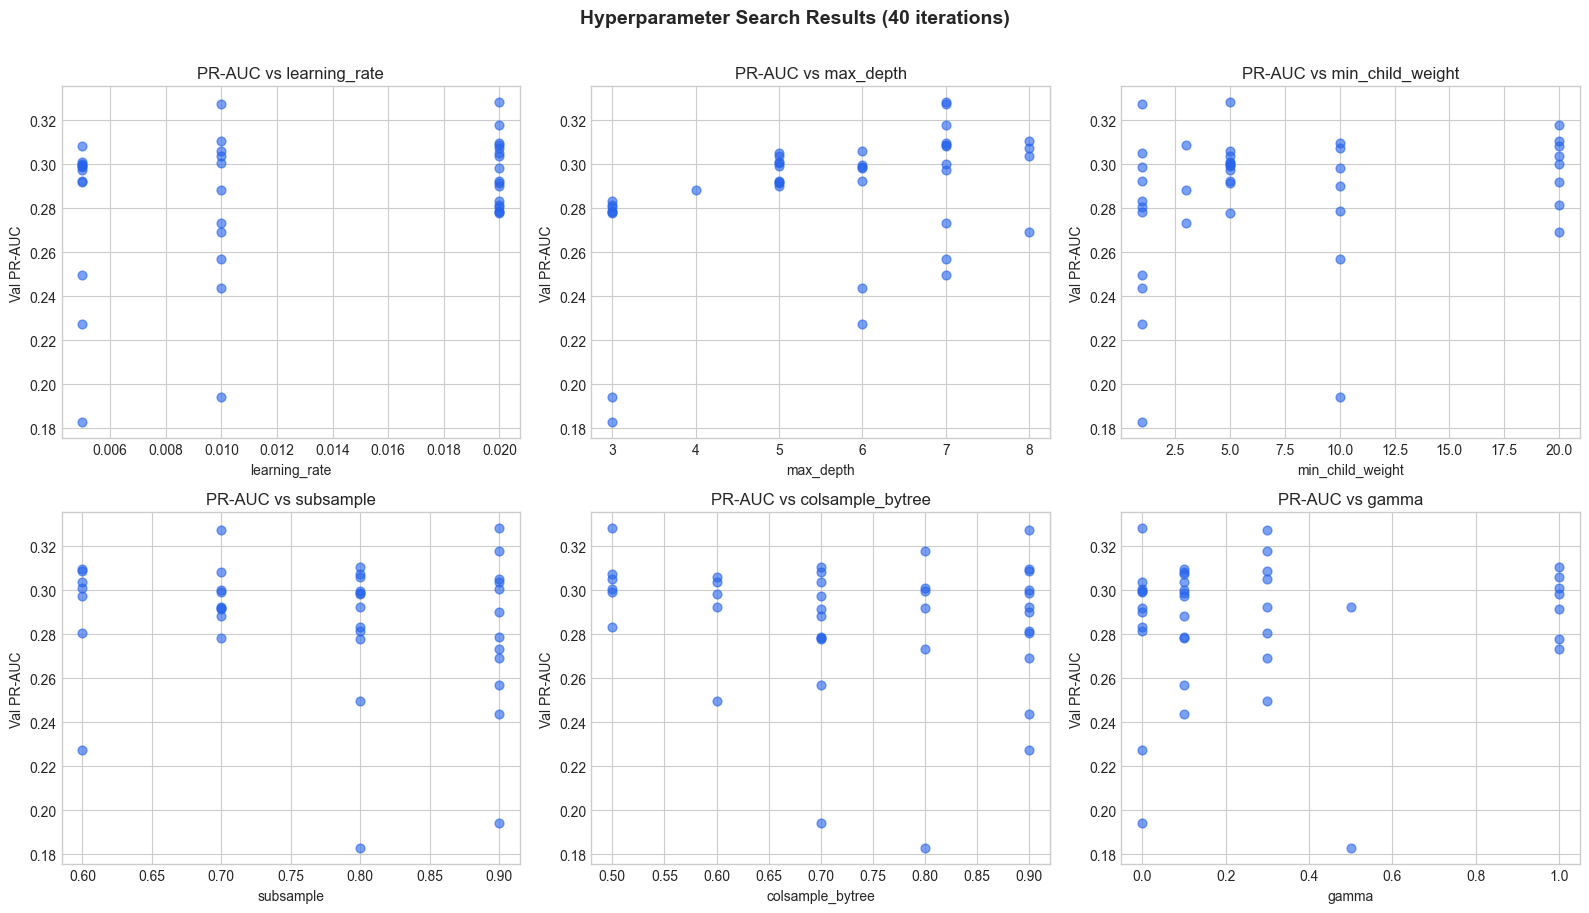


PR-AUC range across search: 0.1827 - 0.3281
Median: 0.2949


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# PR-AUC vs key hyperparameters
for ax, param in zip(axes.flatten(), ["learning_rate", "max_depth", "min_child_weight",
                                       "subsample", "colsample_bytree", "gamma"]):
    ax.scatter(tuning_df[param], tuning_df["val_pr_auc"], alpha=0.6, s=40, color="#2563eb")
    ax.set_xlabel(param)
    ax.set_ylabel("Val PR-AUC")
    ax.set_title(f"PR-AUC vs {param}")

plt.suptitle("Hyperparameter Search Results (40 iterations)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print(f"\nPR-AUC range across search: {tuning_df['val_pr_auc'].min():.4f} - {tuning_df['val_pr_auc'].max():.4f}")
print(f"Median: {tuning_df['val_pr_auc'].median():.4f}")

### Best Model - Retrain

Retrain the best configuration with a low learning rate and generous tree budget, letting early stopping find the optimal iteration count.

In [11]:
best_params = tuning_df.iloc[0].to_dict()
best_params = {k: int(v) if k in INT_PARAMS else v
               for k, v in best_params.items() if k in param_grid.keys()}

print("Best hyperparameters:")
for k, v in sorted(best_params.items()):
    print(f"  {k}: {v}")

model = xgb.XGBClassifier(
    n_estimators=5000,
    scale_pos_weight=scale_pos,
    eval_metric="aucpr",
    early_stopping_rounds=100,
    random_state=42,
    **best_params,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100,
)
print(f"\nBest iteration: {model.best_iteration}")

Best hyperparameters:
  colsample_bytree: 0.5
  gamma: 0.0
  learning_rate: 0.02
  max_depth: 7
  min_child_weight: 5
  reg_alpha: 1.0
  reg_lambda: 10.0
  subsample: 0.9
[0]	validation_0-aucpr:0.16487


[100]	validation_0-aucpr:0.27404


[200]	validation_0-aucpr:0.28859


[300]	validation_0-aucpr:0.30029


[400]	validation_0-aucpr:0.30858


...

[1900]	validation_0-aucpr:0.35265


[2000]	validation_0-aucpr:0.35273


[2100]	validation_0-aucpr:0.35317


[2123]	validation_0-aucpr:0.35274



Best iteration: 2023


### Threshold Optimization

The default 0.5 classification threshold is arbitrary. Optimize the threshold on the validation set using the F1 score to balance precision and recall, then apply it to the test set.

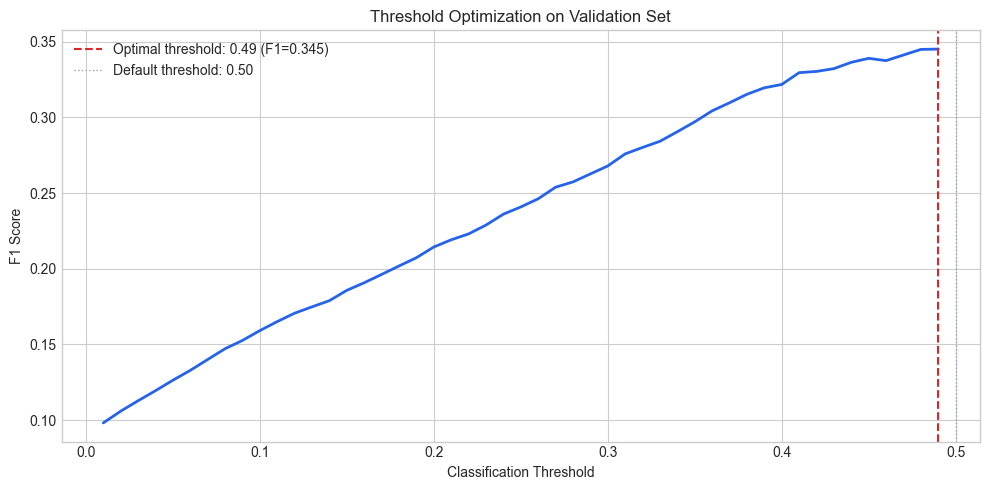

Optimal threshold: 0.49
F1 at optimal:     0.345
F1 at 0.50:        0.352


In [12]:
from sklearn.metrics import f1_score

y_prob_val = model.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.01, 0.50, 0.01)
f1_scores = [f1_score(y_val, (y_prob_val >= t).astype(int)) for t in thresholds]

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, f1_scores, lw=2, color="#2563eb")
ax.axvline(best_threshold, color="#dc2626", ls="--", lw=1.5,
           label=f"Optimal threshold: {best_threshold:.2f} (F1={best_f1:.3f})")
ax.axvline(0.5, color="#94a3b8", ls=":", lw=1, label="Default threshold: 0.50")
ax.set_xlabel("Classification Threshold")
ax.set_ylabel("F1 Score")
ax.set_title("Threshold Optimization on Validation Set")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Optimal threshold: {best_threshold:.2f}")
print(f"F1 at optimal:     {best_f1:.3f}")
print(f"F1 at 0.50:        {f1_score(y_val, (y_prob_val >= 0.5).astype(int)):.3f}")

## Model Evaluation

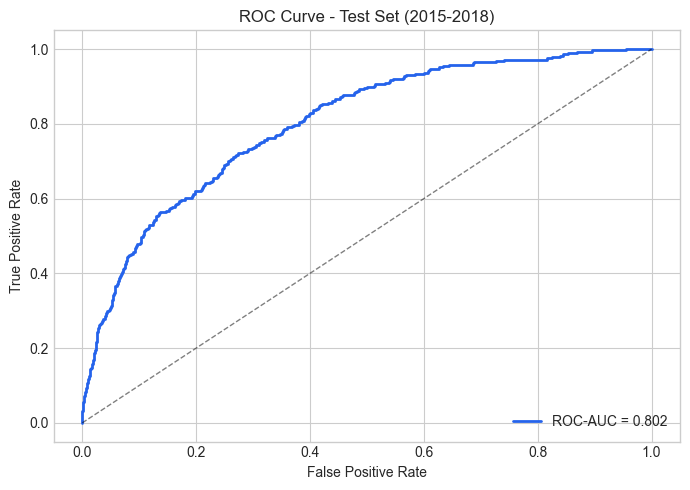

In [13]:
y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color="#2563eb", lw=2, label=f"ROC-AUC = {roc_auc:.3f}")
ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve - Test Set (2015-2018)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

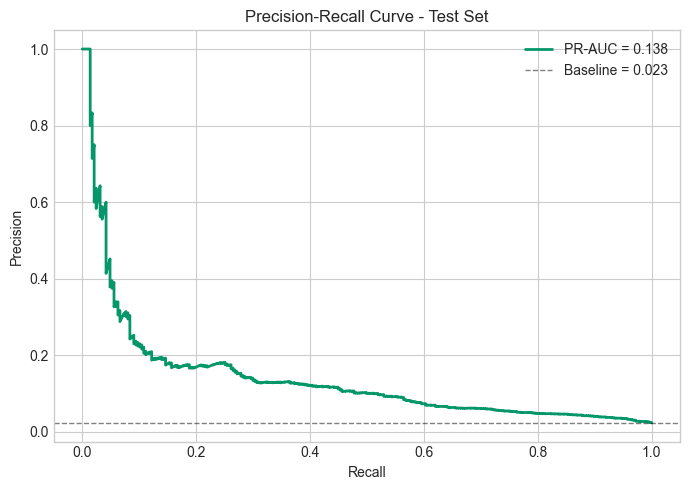

In [14]:
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision, color="#059669", lw=2, label=f"PR-AUC = {pr_auc:.3f}")
ax.axhline(y=y_test.mean(), color="k", linestyle="--", lw=1, alpha=0.5, label=f"Baseline = {y_test.mean():.3f}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve - Test Set")
ax.legend()
plt.tight_layout()
plt.show()

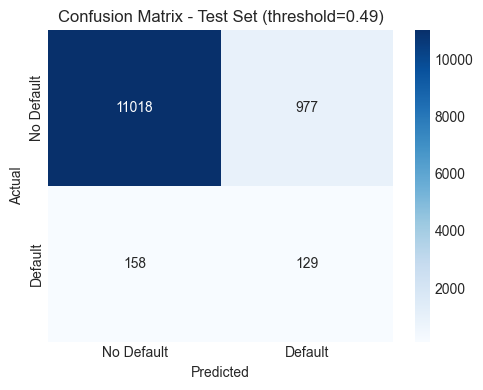

              precision    recall  f1-score   support

  No Default       0.99      0.92      0.95     11995
     Default       0.12      0.45      0.19       287

    accuracy                           0.91     12282
   macro avg       0.55      0.68      0.57     12282
weighted avg       0.97      0.91      0.93     12282



In [15]:
y_pred = (y_prob >= best_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["No Default", "Default"],
            yticklabels=["No Default", "Default"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix - Test Set (threshold={best_threshold:.2f})")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=["No Default", "Default"]))

## SHAP Feature Importance

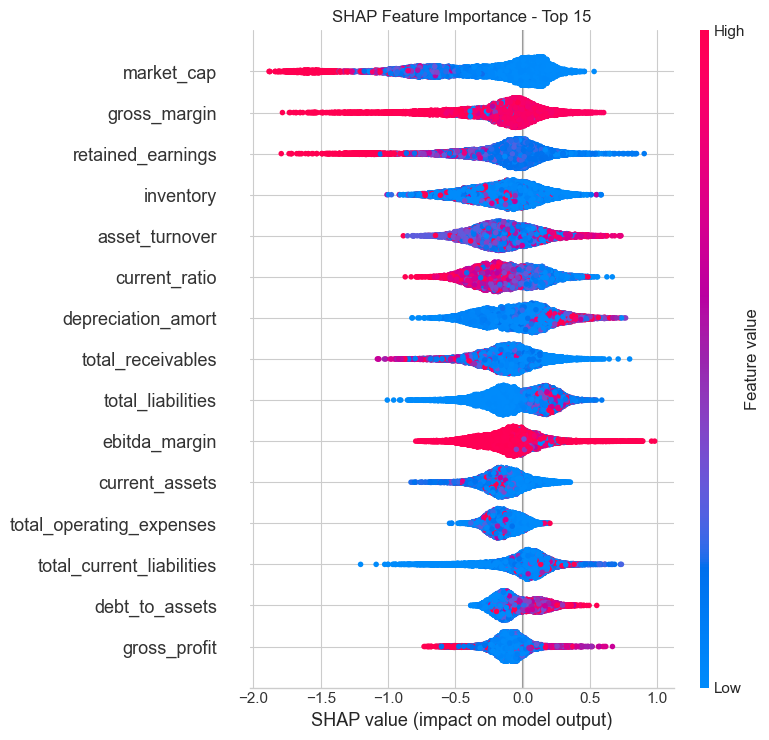

In [16]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.title("SHAP Feature Importance - Top 15")
plt.tight_layout()
plt.show()

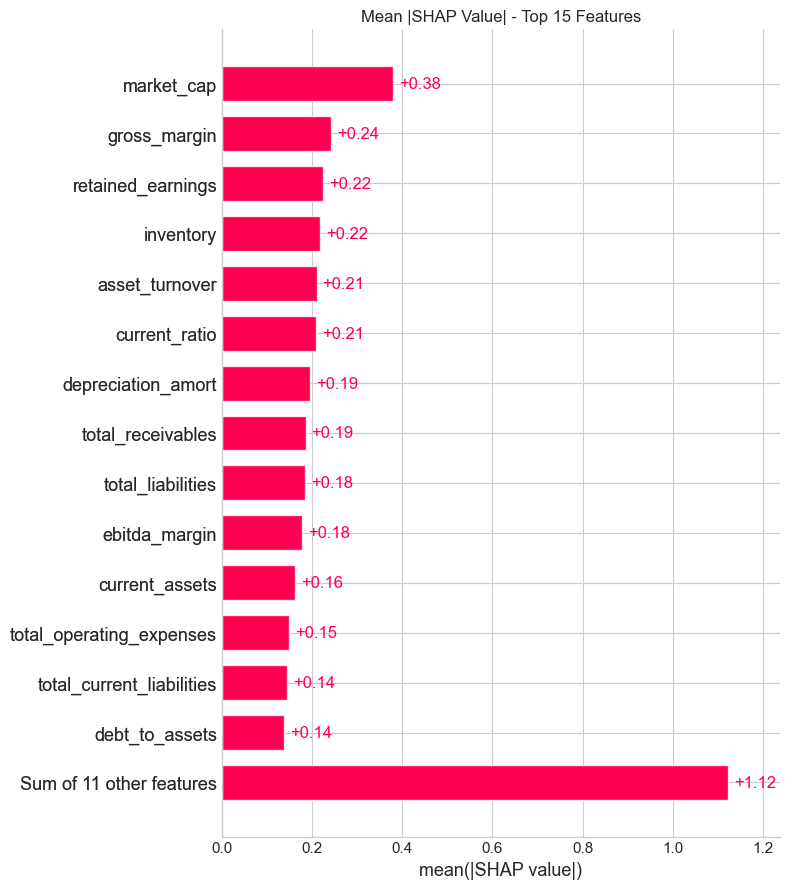

In [17]:
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title("Mean |SHAP Value| - Top 15 Features")
plt.tight_layout()
plt.show()

## Results

Metrics below reflect the tuned model (40-iteration randomized search, low learning rate with early stopping, threshold optimized on validation set).

| Component | Detail |
|-----------|--------|
| **Tuning** | 40-iteration randomized search over 8 hyperparameters |
| **Learning rate** | Tuned from grid [0.005, 0.01, 0.02] with up to 5,000 trees |
| **Early stopping** | Patience of 100 rounds on validation PR-AUC |
| **Threshold** | Optimized on validation F1 (not default 0.50) |
| **Evaluation** | Test set (2015-2018) untouched during tuning |

The temporal split is deliberately conservative - the model must generalize from a high-default training environment (1999-2011, 8% default rate) to a low-default test period (2015-2018, 2.3% default rate) without data leakage.